# BraTS 2023 Multimodal nnU-Net Pipeline, Fixed

This notebook replaces the earlier T1c-only experiment with a safer BraTS-style pipeline:

- raw BraTS case folders are used directly, so training and inference follow the same data contract
- all four modalities are exported: T1n, T1c, T2w, T2-FLAIR
- raw BraTS labels are remapped explicitly into contiguous local labels before region-based training
- validation predictions are audited for false-positive anatomy, connected components, and voxel-ratio failures
- postprocessing is selected from validation behavior, not guessed from a single image

The key label contract in this notebook is:

| Raw BraTS | Meaning | Local label |
| --- | --- | --- |
| 0 | background | 0 |
| 2 | edema | 1 |
| 1 | necrotic / non-enhancing tumor core | 2 |
| 4 | enhancing tumor | 3 |

The region contract then becomes:

- whole tumor = `[1, 2, 3]`
- tumor core = `[2, 3]`
- enhancing tumor = `3`


## 1. Install dependencies


In [1]:
%pip install -q nibabel scipy scikit-image matplotlib ipywidgets pandas nnunetv2
        


## 2. Imports, reproducibility, and runtime helpers


In [3]:
from __future__ import annotations

import csv
import datetime as dt
import json
import os
import random
import re
import shutil
import signal
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from scipy.spatial import cKDTree

SEED = int(os.environ.get("BRATS_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)


def run_command(command: list[str], *, stream: bool = False, check: bool = True) -> subprocess.CompletedProcess | None:
    print("Running:", " ".join(str(x) for x in command))
    env = os.environ.copy()

    if not stream:
        result = subprocess.run(command, text=True, capture_output=True, env=env)
        if result.stdout:
            print(result.stdout)
        if result.returncode != 0 and result.stderr:
            print(result.stderr)
        if check and result.returncode != 0:
            raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(command)}")
        return result

    popen_kwargs = {
        "stdout": subprocess.PIPE,
        "stderr": subprocess.STDOUT,
        "text": True,
        "bufsize": 1,
        "env": env,
    }
    if os.name != "nt":
        popen_kwargs["preexec_fn"] = os.setsid
    proc = subprocess.Popen(command, **popen_kwargs)
    try:
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end="")
        proc.wait()
    except KeyboardInterrupt:
        if os.name == "nt":
            proc.terminate()
        else:
            os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
        print("\nInterrupted. Completed epochs should remain available as checkpoint_latest.pth.")
        raise

    if check and proc.returncode not in (0, -15):
        raise RuntimeError(f"Command failed with exit code {proc.returncode}: {' '.join(command)}")
    return None


def first_existing(paths: list[Path]) -> Path | None:
    for path in paths:
        if path.exists():
            return path
    return None


def reset_dir(path: Path) -> None:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


print("Python:", sys.version)
print("Seed:", SEED)
        


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Seed: 42


## 3. Mount Drive and locate data


In [4]:
IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None

if IN_COLAB:
    drive.mount("/content/drive")

PROJECT_ROOT = first_existing([
    Path("/content/drive/MyDrive/gp2"),
    Path("/content/gp2"),
    Path.cwd(),
]).resolve()

DATA_ROOT = first_existing([
    Path("/content/drive/MyDrive/Brats_Final_Data"),
    Path("/content/drive/MyDrive/Brats Final Data"),
    Path("C:/Users/MSI/Downloads/Brats_Final_Data"),
    Path("C:/Users/MSI/Downloads/Brats Final Data"),
])

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find Brats_Final_Data. Mount Drive or update DATA_ROOT.")
DATA_ROOT = DATA_ROOT.resolve()

RAW_TRAIN_ROOTS = {
    "glioma": DATA_ROOT / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData",
    "meningioma": DATA_ROOT / "ASNR-MICCAI-BraTS2023-MEN-Challenge-TrainingData",
}

RAW_VAL_ROOTS = {
    "glioma": DATA_ROOT / "ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData",
    "meningioma": DATA_ROOT / "ASNR-MICCAI-BraTS2023-MEN-Challenge-ValidationData",
}

for name, path in RAW_TRAIN_ROOTS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing raw training folder for {name}: {path}")

WORKSPACE_DIR = Path(os.environ.get("BRATS_WORKSPACE_DIR", str(PROJECT_ROOT / "brats_multimodal_workspace"))).resolve()
CHECKPOINT_ROOT = Path(os.environ.get("BRATS_CHECKPOINT_ROOT", str(PROJECT_ROOT / "checkpoints"))).resolve()
BACKUP_ROOT = Path(os.environ.get("BRATS_BACKUP_ROOT", str(PROJECT_ROOT / "brats_multimodal_backups"))).resolve()

WORKSPACE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

print("Running in Colab:", IN_COLAB)
print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Workspace:", WORKSPACE_DIR)
print("Checkpoint root:", CHECKPOINT_ROOT)
print("Backup root:", BACKUP_ROOT)
print("Raw train roots:", RAW_TRAIN_ROOTS)
print("Raw validation roots:", RAW_VAL_ROOTS)
        


Mounted at /content/drive
Running in Colab: True
Project root: /content/drive/MyDrive/gp2
Data root: /content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data
Workspace: /content/drive/MyDrive/gp2/brats_multimodal_workspace
Checkpoint root: /content/drive/MyDrive/gp2/checkpoints
Backup root: /content/drive/MyDrive/gp2/brats_multimodal_backups
Raw train roots: {'glioma': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData'), 'meningioma': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data/ASNR-MICCAI-BraTS2023-MEN-Challenge-TrainingData')}
Raw validation roots: {'glioma': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData'), 'meningioma': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-G

## 4. Pipeline configuration


In [5]:
DATASET_ID = int(os.environ.get("BRATS_DATASET_ID", "304"))
DATASET_NAME = os.environ.get("BRATS_DATASET_NAME", "BraTS2023_GLI_MEN_4modal_Regions")
DATASET_FOLDER = f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"

MODALITIES = [
    ("0000", "t1n", "T1n"),
    ("0001", "t1c", "T1c"),
    ("0002", "t2w", "T2w"),
    ("0003", "t2f", "T2-FLAIR"),
]

CONFIGURATION = os.environ.get("BRATS_CONFIGURATION", "3d_fullres")
RESENC_PRESET = os.environ.get("BRATS_RESENC_PRESET", "M").strip().upper()
if RESENC_PRESET not in {"M", "L", "XL"}:
    raise ValueError("BRATS_RESENC_PRESET must be one of M, L, XL")

PLANNER_NAME = os.environ.get("BRATS_PLANNER_NAME", f"nnUNetPlannerResEnc{RESENC_PRESET}")
PLANS_NAME = os.environ.get("BRATS_PLANS_NAME", f"nnUNetResEncUNet{RESENC_PRESET}Plans")
MAX_EPOCHS = int(os.environ.get("BRATS_MAX_EPOCHS", "250"))
SAVE_EVERY_N_EPOCHS = int(os.environ.get("BRATS_SAVE_EVERY_N_EPOCHS", "25"))
TRAINER_NAME = os.environ.get("BRATS_TRAINER_NAME", f"nnUNetTrainerBudget{MAX_EPOCHS}Epochs")

requested_folds = os.environ.get("BRATS_TRAIN_FOLDS", "0")
TRAIN_FOLDS = [int(x.strip()) for x in requested_folds.split(",") if x.strip()]
if not TRAIN_FOLDS:
    TRAIN_FOLDS = [0]
if any(fold not in {0, 1, 2, 3, 4} for fold in TRAIN_FOLDS):
    raise ValueError(f"Invalid folds: {TRAIN_FOLDS}")
ALLOW_MULTI_FOLD = os.environ.get("BRATS_ALLOW_MULTI_FOLD", "0") == "1"
if len(TRAIN_FOLDS) > 1 and not ALLOW_MULTI_FOLD:
    print("Keeping only the first requested fold. Set BRATS_ALLOW_MULTI_FOLD=1 to train multiple folds.")
    TRAIN_FOLDS = TRAIN_FOLDS[:1]

NNUNET_RAW = WORKSPACE_DIR / "nnUNet_raw"
NNUNET_PREPROCESSED = WORKSPACE_DIR / "nnUNet_preprocessed"
NNUNET_RESULTS = CHECKPOINT_ROOT
DATASET_ROOT = NNUNET_RAW / DATASET_FOLDER
IMAGES_TR = DATASET_ROOT / "imagesTr"
LABELS_TR = DATASET_ROOT / "labelsTr"
IMAGES_TS = DATASET_ROOT / "imagesTs"
MODEL_BASE = NNUNET_RESULTS / DATASET_FOLDER / f"{TRAINER_NAME}__{PLANS_NAME}__{CONFIGURATION}"

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
os.environ["nnUNet_results"] = str(NNUNET_RESULTS)
os.environ["BRATS_CHECKPOINT_MIRROR"] = str(MODEL_BASE)

print("Dataset folder:", DATASET_FOLDER)
print("Modalities:", MODALITIES)
print("Trainer:", TRAINER_NAME)
print("Planner:", PLANNER_NAME)
print("Plans:", PLANS_NAME)
print("Configuration:", CONFIGURATION)
print("Train folds:", TRAIN_FOLDS)
print("Max epochs:", MAX_EPOCHS)
print("Model base:", MODEL_BASE)
        


Dataset folder: Dataset304_BraTS2023_GLI_MEN_4modal_Regions
Modalities: [('0000', 't1n', 'T1n'), ('0001', 't1c', 'T1c'), ('0002', 't2w', 'T2w'), ('0003', 't2f', 'T2-FLAIR')]
Trainer: nnUNetTrainerBudget250Epochs
Planner: nnUNetPlannerResEncM
Plans: nnUNetResEncUNetMPlans
Configuration: 3d_fullres
Train folds: [0]
Max epochs: 250
Model base: /content/drive/MyDrive/gp2/checkpoints/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres


## 5. Discover raw BraTS cases


In [6]:
def sanitize_case_id(text: str) -> str:
    text = text.replace(".nii.gz", "").replace(".nii", "")
    value = re.sub(r"[^A-Za-z0-9_]+", "_", text.strip())
    value = re.sub(r"_+", "_", value).strip("_")
    if not value:
        raise ValueError(f"Invalid case id from {text!r}")
    return value


def discover_raw_cases(roots: dict[str, Path], *, require_seg: bool) -> tuple[list[dict], list[dict]]:
    rows = []
    skipped = []
    for tumor_type, root in roots.items():
        if not root.exists():
            skipped.append({"tumor_type": tumor_type, "path": str(root), "reason": "missing root"})
            continue
        for case_dir in sorted(p for p in root.iterdir() if p.is_dir()):
            case_name = case_dir.name
            files = {}
            for _, suffix, _ in MODALITIES:
                matches = sorted(case_dir.glob(f"*-{suffix}.nii.gz"))
                if len(matches) == 1:
                    files[suffix] = matches[0]
            seg_matches = sorted(case_dir.glob("*-seg.nii.gz"))
            if len(seg_matches) == 1:
                files["seg"] = seg_matches[0]

            missing = [suffix for _, suffix, _ in MODALITIES if suffix not in files]
            if require_seg and "seg" not in files:
                missing.append("seg")
            if missing:
                skipped.append({
                    "tumor_type": tumor_type,
                    "case": case_name,
                    "path": str(case_dir),
                    "reason": f"missing {missing}",
                })
                continue

            rows.append({
                "case_id": sanitize_case_id(case_name),
                "raw_case_id": case_name,
                "tumor_type": tumor_type,
                "case_dir": case_dir,
                "modalities": {suffix: files[suffix] for _, suffix, _ in MODALITIES},
                "seg": files.get("seg"),
            })
    return rows, skipped


train_cases, train_skipped = discover_raw_cases(RAW_TRAIN_ROOTS, require_seg=True)
external_cases, external_skipped = discover_raw_cases(RAW_VAL_ROOTS, require_seg=False)

print("Training cases:", len(train_cases))
print("Training skipped:", len(train_skipped))
print("External/validation cases:", len(external_cases))
print("External/validation skipped:", len(external_skipped))
print("Training class counts:", Counter(row["tumor_type"] for row in train_cases))
print("First training case:", train_cases[0] if train_cases else None)

if not train_cases:
    raise RuntimeError("No valid training cases were discovered.")
        


Training cases: 2251
Training skipped: 0
External/validation cases: 360
External/validation skipped: 0
Training class counts: Counter({'glioma': 1251, 'meningioma': 1000})
First training case: {'case_id': 'BraTS_GLI_00000_000', 'raw_case_id': 'BraTS-GLI-00000-000', 'tumor_type': 'glioma', 'case_dir': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000'), 'modalities': {'t1n': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1n.nii.gz'), 't1c': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBxCI/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii.gz'), 't2w': PosixPath('/content/drive/.shortcut-targets-by-id/1I84smosqbBDc2H4L1i2X-GFMO35kBx

## 6. Geometry and label sanity checks


In [6]:
def load_nifti_header(path: Path) -> nib.Nifti1Image:
    return nib.load(str(path))


def load_seg_array(path: Path) -> tuple[np.ndarray, nib.Nifti1Image]:
    img = nib.load(str(path))
    data = np.asanyarray(img.dataobj)
    if data.ndim == 4 and data.shape[-1] == 1:
        data = data[..., 0]
    return data, img


def image_signature(img: nib.Nifti1Image) -> dict:
    return {
        "shape": tuple(int(v) for v in img.shape[:3]),
        "spacing": tuple(float(v) for v in img.header.get_zooms()[:3]),
        "ndim": int(len(img.shape)),
    }


def check_case_geometry(case: dict) -> list[str]:
    messages = []
    ref_sig = None

    # Check modality files using header info only
    for _, suffix, display_name in MODALITIES:
        img = load_nifti_header(case["modalities"][suffix])
        sig = image_signature(img)

        if sig["ndim"] != 3:
            messages.append(f"{display_name} is not 3D: ndim={sig['ndim']}, shape={img.shape}")

        if ref_sig is None:
            ref_sig = sig
        else:
            if sig["shape"] != ref_sig["shape"]:
                messages.append(
                    f"{display_name} shape mismatch: {sig['shape']} vs {ref_sig['shape']}"
                )
            if sig["spacing"] != ref_sig["spacing"]:
                messages.append(
                    f"{display_name} spacing mismatch: {sig['spacing']} vs {ref_sig['spacing']}"
                )

    # Check segmentation geometry from header, then labels from data
    if case.get("seg") is not None:
        seg_img = load_nifti_header(case["seg"])
        seg_sig = image_signature(seg_img)

        if seg_sig["ndim"] != 3:
            messages.append(f"seg is not 3D: ndim={seg_sig['ndim']}, shape={seg_img.shape}")

        if ref_sig is not None and seg_sig["shape"] != ref_sig["shape"]:
            messages.append(
                f"seg shape mismatch: {seg_sig['shape']} vs {ref_sig['shape']}"
            )

        if ref_sig is not None and seg_sig["spacing"] != ref_sig["spacing"]:
            messages.append(
                f"seg spacing mismatch: {seg_sig['spacing']} vs {ref_sig['spacing']}"
            )

        seg, _ = load_seg_array(case["seg"])
        labels = sorted(int(v) for v in np.unique(seg))

        # Accept raw BraTS labels or already-remapped local labels
        if not (set(labels).issubset({0, 1, 2, 4}) or set(labels).issubset({0, 1, 2, 3})):
            messages.append(f"unexpected raw labels: {labels}")

    return messages


geometry_errors = []

print(f"Checking geometry and labels for {len(train_cases)} training cases...")

for i, case in enumerate(train_cases, start=1):
    try:
        messages = check_case_geometry(case)
        if messages:
            geometry_errors.append(
                {
                    "case_id": case["case_id"],
                    "raw_case_id": case["raw_case_id"],
                    "messages": messages,
                }
            )

        if i <= 3:
            print(case["case_id"], "geometry messages:", messages or "ok")

        if i % 25 == 0 or i == len(train_cases):
            print(
                f"[{i}/{len(train_cases)}] checked | errors so far: {len(geometry_errors)}"
            )

    except Exception as exc:
        geometry_errors.append(
            {
                "case_id": case["case_id"],
                "raw_case_id": case["raw_case_id"],
                "messages": [f"exception while checking case: {repr(exc)}"],
            }
        )
        print(f"[{i}/{len(train_cases)}] ERROR in {case['case_id']}: {exc}")

print("Cases with geometry/label warnings:", len(geometry_errors))

if geometry_errors[:10]:
    print(json.dumps(geometry_errors[:10], indent=2))

if geometry_errors:
    raise RuntimeError(
        "Fix geometry/label warnings before export. See geometry_errors."
    )
else:
    print("Geometry and label sanity checks passed.")


Checking geometry and labels for 2251 training cases...
BraTS_GLI_00000_000 geometry messages: ok
BraTS_GLI_00002_000 geometry messages: ok
BraTS_GLI_00003_000 geometry messages: ok


KeyboardInterrupt: 

## 7. Correct BraTS label remapping


In [7]:
def load_nifti(path: Path) -> tuple[np.ndarray, nib.Nifti1Image]:
    img = nib.load(str(path))
    data = np.asanyarray(img.dataobj)
    if data.ndim == 4 and data.shape[-1] == 1:
        data = data[..., 0]
    return data, img


In [8]:
RAW_TO_LOCAL = {
    0: 0,
    2: 1,  # edema
    1: 2,  # necrotic/non-enhancing tumor core
    4: 3,  # enhancing tumor
}

LOCAL_LABEL_NAMES = {
    0: "background",
    1: "edema",
    2: "non_enhancing_or_necrotic_core",
    3: "enhancing_tumor",
}


def remap_brats_labels(seg: np.ndarray) -> np.ndarray:
    labels = set(int(v) for v in np.unique(seg))
    if labels.issubset({0, 1, 2, 4}):
        out = np.zeros(seg.shape, dtype=np.uint8)
        for raw, local in RAW_TO_LOCAL.items():
            out[seg == raw] = local
        return out

    # Allow already-local masks, but only if label 4 is absent.
    if labels.issubset({0, 1, 2, 3}) and 4 not in labels:
        return seg.astype(np.uint8)

    raise ValueError(f"Unexpected label set {sorted(labels)}. Expected raw BraTS {{0,1,2,4}} or local {{0,1,2,3}}.")


label_counter = Counter()
region_presence = Counter()
for case in train_cases:
    seg, _ = load_nifti(case["seg"])
    local = remap_brats_labels(seg)
    label_counter.update(int(v) for v in np.unique(local))
    region_presence["whole_tumor"] += int(np.any(np.isin(local, [1, 2, 3])))
    region_presence["tumor_core"] += int(np.any(np.isin(local, [2, 3])))
    region_presence["enhancing_tumor"] += int(np.any(local == 3))

print("Local labels seen:", dict(sorted(label_counter.items())))
print("Local label names:", LOCAL_LABEL_NAMES)
print("Cases containing regions:", dict(region_presence))
        


Local labels seen: {0: 2251, 1: 1553, 2: 1780, 3: 2217}
Local label names: {0: 'background', 1: 'edema', 2: 'non_enhancing_or_necrotic_core', 3: 'enhancing_tumor'}
Cases containing regions: {'whole_tumor': 2251, 'tumor_core': 2245, 'enhancing_tumor': 2217}


## 8. Visual sanity check for modalities and remapped labels


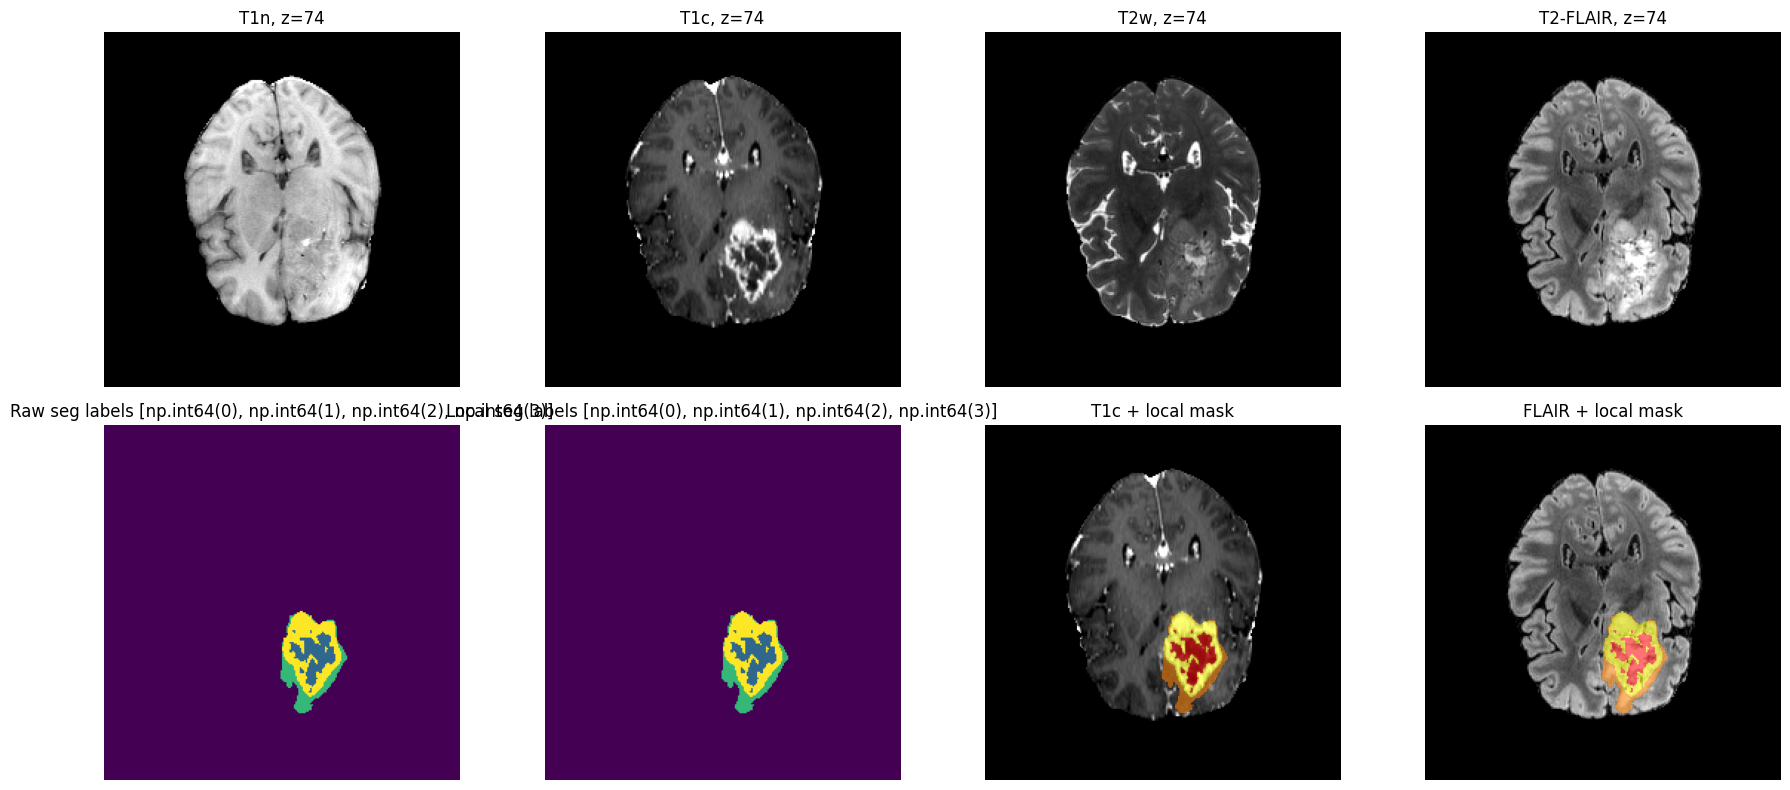

In [12]:
import matplotlib.pyplot as plt


def normalize_slice(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    nonzero = x[x != 0]
    values = nonzero if nonzero.size else x.reshape(-1)
    lo, hi = np.percentile(values, [1, 99])
    if hi <= lo:
        return x
    return np.clip((x - lo) / (hi - lo), 0, 1)


def best_label_slice(mask: np.ndarray) -> int:
    scores = (mask > 0).sum(axis=(0, 1))
    return int(np.argmax(scores)) if scores.max() > 0 else mask.shape[2] // 2


case = train_cases[0]
vols = {}
for _, suffix, display_name in MODALITIES:
    vols[display_name], _ = load_nifti(case["modalities"][suffix])
raw_seg, _ = load_nifti(case["seg"])
local_seg = remap_brats_labels(raw_seg)
z = best_label_slice(local_seg)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (name, vol) in zip(axes[0], vols.items()):
    ax.imshow(np.rot90(normalize_slice(vol[:, :, z])), cmap="gray")
    ax.set_title(f"{name}, z={z}")
    ax.axis("off")

axes[1, 0].imshow(np.rot90(raw_seg[:, :, z]), cmap="viridis", vmin=0)
axes[1, 0].set_title(f"Raw seg labels {sorted(np.unique(raw_seg).astype(int))}")
axes[1, 1].imshow(np.rot90(local_seg[:, :, z]), cmap="viridis", vmin=0, vmax=3)
axes[1, 1].set_title(f"Local seg labels {sorted(np.unique(local_seg).astype(int))}")
axes[1, 2].imshow(np.rot90(normalize_slice(vols["T1c"][:, :, z])), cmap="gray")
axes[1, 2].imshow(np.ma.masked_where(np.rot90(local_seg[:, :, z]) == 0, np.rot90(local_seg[:, :, z])), cmap="autumn", alpha=0.55)
axes[1, 2].set_title("T1c + local mask")
axes[1, 3].imshow(np.rot90(normalize_slice(vols["T2-FLAIR"][:, :, z])), cmap="gray")
axes[1, 3].imshow(np.ma.masked_where(np.rot90(local_seg[:, :, z]) == 0, np.rot90(local_seg[:, :, z])), cmap="autumn", alpha=0.55)
axes[1, 3].set_title("FLAIR + local mask")

for ax in axes[1]:
    ax.axis("off")
plt.tight_layout()
plt.show()
        


## 9. Export nnU-Net raw dataset


In [9]:
def save_nifti(data: np.ndarray, reference_img: nib.Nifti1Image, dst: Path, dtype=np.float32) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    out = nib.Nifti1Image(np.asarray(data, dtype=dtype), reference_img.affine)
    out.header.set_zooms(reference_img.header.get_zooms()[:3])
    nib.save(out, str(dst))


def export_case(case: dict, image_dir: Path, label_dir: Path | None) -> None:
    for channel, suffix, _ in MODALITIES:
        data, img = load_nifti(case["modalities"][suffix])
        save_nifti(data.astype(np.float32), img, image_dir / f"{case['case_id']}_{channel}.nii.gz", dtype=np.float32)
    if label_dir is not None:
        seg, seg_img = load_nifti(case["seg"])
        local_seg = remap_brats_labels(seg)
        save_nifti(local_seg, seg_img, label_dir / f"{case['case_id']}.nii.gz", dtype=np.uint8)


RESET_EXPORTS = False  # Set True only when you intentionally want to rebuild this dataset from scratch.

def training_case_complete(case: dict) -> bool:
    case_id = case["case_id"]
    image_files_ok = all((IMAGES_TR / f"{case_id}_{channel}.nii.gz").exists() for channel, _, _ in MODALITIES)
    return image_files_ok and (LABELS_TR / f"{case_id}.nii.gz").exists()


def external_case_complete(case: dict) -> bool:
    case_id = case["case_id"]
    return all((IMAGES_TS / f"{case_id}_{channel}.nii.gz").exists() for channel, _, _ in MODALITIES)


if RESET_EXPORTS:
    reset_dir(DATASET_ROOT)
IMAGES_TR.mkdir(parents=True, exist_ok=True)
LABELS_TR.mkdir(parents=True, exist_ok=True)
IMAGES_TS.mkdir(parents=True, exist_ok=True)

skipped_train = 0
exported_train = 0
for i, case in enumerate(train_cases, start=1):
    if not RESET_EXPORTS and training_case_complete(case):
        skipped_train += 1
    else:
        export_case(case, IMAGES_TR, LABELS_TR)
        exported_train += 1
    if i % 100 == 0:
        print(f"Exported {i}/{len(train_cases)} training cases")

skipped_external = 0
exported_external = 0
for i, case in enumerate(external_cases, start=1):
    if not RESET_EXPORTS and external_case_complete(case):
        skipped_external += 1
    else:
        export_case(case, IMAGES_TS, None)
        exported_external += 1
    if i % 100 == 0:
        print(f"Exported {i}/{len(external_cases)} external/validation cases")

print(f"Training cases skipped/exported: {skipped_train}/{exported_train}")
print(f"External cases skipped/exported: {skipped_external}/{exported_external}")
print("Training images:", len(list(IMAGES_TR.glob("*_0000.nii.gz"))))
print("Training labels:", len(list(LABELS_TR.glob("*.nii.gz"))))
print("External images:", len(list(IMAGES_TS.glob("*_0000.nii.gz"))))
        


Exported 100/2251 training cases
Exported 200/2251 training cases
Exported 300/2251 training cases
Exported 400/2251 training cases
Exported 500/2251 training cases
Exported 600/2251 training cases
Exported 700/2251 training cases
Exported 800/2251 training cases
Exported 900/2251 training cases
Exported 1000/2251 training cases
Exported 1100/2251 training cases
Exported 1200/2251 training cases
Exported 1300/2251 training cases
Exported 1400/2251 training cases
Exported 1500/2251 training cases
Exported 1600/2251 training cases
Exported 1700/2251 training cases
Exported 1800/2251 training cases
Exported 1900/2251 training cases
Exported 2000/2251 training cases
Exported 2100/2251 training cases
Exported 2200/2251 training cases
Exported 100/360 external/validation cases
Exported 200/360 external/validation cases
Exported 300/360 external/validation cases
Training cases skipped/exported: 2251/0
External cases skipped/exported: 360/0
Training images: 2251
Training labels: 2251
External 

## 10. Write dataset.json


In [10]:
dataset_json = {
    "channel_names": {str(i): display_name for i, (_, _, display_name) in enumerate(MODALITIES)},
    "labels": {
        "background": 0,
        "whole_tumor": [1, 2, 3],
        "tumor_core": [2, 3],
        "enhancing_tumor": 3,
    },
    "regions_class_order": [1, 2, 3],
    "numTraining": len(train_cases),
    "file_ending": ".nii.gz",
}

dataset_json_path = DATASET_ROOT / "dataset.json"
dataset_json_path.write_text(json.dumps(dataset_json, indent=2), encoding="utf-8")
print(dataset_json_path)
print(dataset_json_path.read_text(encoding="utf-8"))
        


/content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_raw/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/dataset.json
{
  "channel_names": {
    "0": "T1n",
    "1": "T1c",
    "2": "T2w",
    "3": "T2-FLAIR"
  },
  "labels": {
    "background": 0,
    "whole_tumor": [
      1,
      2,
      3
    ],
    "tumor_core": [
      2,
      3
    ],
    "enhancing_tumor": 3
  },
  "regions_class_order": [
    1,
    2,
    3
  ],
  "numTraining": 2251,
  "file_ending": ".nii.gz"
}


## 11. Install consistent budget trainer


In [16]:
def install_budget_trainer() -> Path:
    import nnunetv2

    trainer_dir = Path(nnunetv2.__file__).parent / "training" / "nnUNetTrainer"
    trainer_path = trainer_dir / f"{TRAINER_NAME}.py"
    trainer_code = f'''
import json
import os
import shutil
from pathlib import Path

import torch

from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer


class {TRAINER_NAME}(nnUNetTrainer):
    def __init__(self, plans, configuration, fold, dataset_json, device=torch.device("cuda")):
        super().__init__(plans, configuration, fold, dataset_json, device)
        self.num_epochs = {MAX_EPOCHS}
        self.save_every = {SAVE_EVERY_N_EPOCHS}

    def save_checkpoint(self, filename: str, *args, **kwargs) -> None:
        super().save_checkpoint(filename, *args, **kwargs)

        mirror_root = os.environ.get("BRATS_CHECKPOINT_MIRROR")
        if not mirror_root:
            return

        source = Path(filename)
        if not source.is_absolute():
            source = Path(self.output_folder) / filename
        if not source.exists():
            return

        target_dir = Path(mirror_root) / f"fold_{{self.fold}}"
        target_dir.mkdir(parents=True, exist_ok=True)
        target = target_dir / source.name
        if source.resolve() != target.resolve():
            shutil.copy2(source, target)

        state = {{
            "fold": int(self.fold),
            "epoch": int(getattr(self, "current_epoch", -1)),
            "checkpoint": source.name,
            "mirrored_to": str(target),
            "output_folder": str(self.output_folder),
        }}
        (target_dir / "latest_mirror_state.json").write_text(json.dumps(state, indent=2), encoding="utf-8")
'''.lstrip()
    trainer_path.write_text(trainer_code, encoding="utf-8")
    return trainer_path


trainer_path = install_budget_trainer()
print("Installed trainer:", trainer_path)
print("Trainer name:", TRAINER_NAME)


Installed trainer: /usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainerBudget250Epochs.py
Trainer name: nnUNetTrainerBudget250Epochs


## 12. Plan and preprocess


In [ ]:
plans_path = NNUNET_PREPROCESSED / DATASET_FOLDER / f"{PLANS_NAME}.json"
dataset_pp = NNUNET_PREPROCESSED / DATASET_FOLDER

print("Plans exists:", plans_path.exists(), plans_path)
print("Preprocessed dataset exists:", dataset_pp.exists(), dataset_pp)

if dataset_pp.exists():
    for p in sorted(dataset_pp.iterdir()):
        print(p.name, "DIR" if p.is_dir() else "FILE")


In [ ]:
# 12. Plan and preprocess, resume-safe with live progress

FORCE_PREPROCESS = False  # Change to True only if you intentionally want to rerun preprocessing.

if "run_command" not in globals():
    raise RuntimeError("run_command is not defined. Rerun section 2: Imports, helpers.")

plans_path = NNUNET_PREPROCESSED / DATASET_FOLDER / f"{PLANS_NAME}.json"
preprocessed_root = NNUNET_PREPROCESSED / DATASET_FOLDER

candidate_config_dirs = []
if preprocessed_root.exists():
    candidate_config_dirs = sorted(
        p for p in preprocessed_root.glob(f"*_{CONFIGURATION}")
        if p.is_dir()
    )

def config_dir_has_cases(path: Path) -> bool:
    if not path.exists():
        return False
    case_files = list(path.glob("*.npy")) + list(path.glob("*.npz"))
    metadata_files = list(path.glob("*.pkl"))
    return len(case_files) > 0 and len(metadata_files) > 0

preprocessed_ready = (
    plans_path.exists()
    and any(config_dir_has_cases(p) for p in candidate_config_dirs)
)

print("Plans path:", plans_path)
print("Plans exists:", plans_path.exists())
print("Preprocessed root:", preprocessed_root)
print("Candidate config dirs:", candidate_config_dirs)
print("Preprocessed ready:", preprocessed_ready)

if preprocessed_ready and not FORCE_PREPROCESS:
    print("Preprocessing already exists. Skipping nnUNetv2_plan_and_preprocess.")
else:
    command = [
        "nnUNetv2_plan_and_preprocess",
        "-d", str(DATASET_ID),
        "--verify_dataset_integrity",
        "-pl", PLANNER_NAME,
    ]

    # stream=True shows live nnU-Net output/progress instead of hiding it for hours.
    run_command(command, stream=True)

if plans_path.exists():
    plans = json.loads(plans_path.read_text(encoding="utf-8"))
    print("Plans path:", plans_path)
    print("Available configurations:", list(plans.get("configurations", {}).keys()))
else:
    raise FileNotFoundError(f"Plans file not found after preprocessing: {plans_path}")

        

Plans path: /content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_preprocessed/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/nnUNetResEncUNetMPlans.json
Plans exists: True
Preprocessed root: /content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_preprocessed/Dataset304_BraTS2023_GLI_MEN_4modal_Regions
Candidate config dirs: [PosixPath('/content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_preprocessed/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/nnUNetPlans_3d_fullres')]
Preprocessed ready: False


NameError: name 'PLANNER_NAME' is not defined

## 13. Train fold(s)


In [17]:
def fold_dir(fold: int) -> Path:
    return MODEL_BASE / f"fold_{fold}"


def fold_finished(fold: int) -> bool:
    return (fold_dir(fold) / "checkpoint_final.pth").exists()


def fold_has_latest(fold: int) -> bool:
    return (fold_dir(fold) / "checkpoint_latest.pth").exists()


MODEL_BASE.mkdir(parents=True, exist_ok=True)
shutil.copy2(DATASET_ROOT / "dataset.json", MODEL_BASE / "dataset.json")
plans_src = NNUNET_PREPROCESSED / DATASET_FOLDER / f"{PLANS_NAME}.json"
if plans_src.exists():
    shutil.copy2(plans_src, MODEL_BASE / "plans.json")

print("Training folds:", TRAIN_FOLDS)
print("Model base:", MODEL_BASE)

for fold in TRAIN_FOLDS:
    fold_dir(fold).mkdir(parents=True, exist_ok=True)
    if fold_finished(fold):
        print(f"Fold {fold} already has checkpoint_final.pth; skipping.")
        continue

    train_command = [
        "nnUNetv2_train",
        str(DATASET_ID),
        CONFIGURATION,
        str(fold),
        "-tr", TRAINER_NAME,
        "-p", PLANS_NAME,
        "--npz",
    ]
    if fold_has_latest(fold):
        train_command.append("--c")
        print(f"Resuming fold {fold} from checkpoint_latest.pth")
    else:
        print(f"Starting fold {fold} from scratch")

    run_command(train_command, stream=True)

print("Training stage complete.")
for fold in TRAIN_FOLDS:
    print(f"Fold {fold} checkpoints:", sorted(p.name for p in fold_dir(fold).glob("checkpoint_*.pth")))
        


Training folds: [0]
Model base: /content/drive/MyDrive/gp2/checkpoints/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres
Starting fold 0 from scratch
Running: nnUNetv2_train 304 3d_fullres 0 -tr nnUNetTrainerBudget250Epochs -p nnUNetResEncUNetMPlans --npz
Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-04-29 17:51:37.079793: Using torch.compile...
2026-04-29 17:51:38.380887: do_dummy_2d_data_aug: False
2026-04-29 17:51:38.474036: Using splits from existing split file: /content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_preprocessed/Dataset304_Br

In [18]:
# Save trained multimodal model to Drive folder: gp2_multimodal

from pathlib import Path
import json
import shutil
import datetime as dt

DRIVE_SAVE_ROOT = Path("/content/drive/MyDrive/gp2_multimodal")
DRIVE_SAVE_ROOT.mkdir(parents=True, exist_ok=True)

SAVE_STAMP = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_SAVE_DIR = DRIVE_SAVE_ROOT / f"{DATASET_FOLDER}_{TRAINER_NAME}__{PLANS_NAME}__{CONFIGURATION}_{SAVE_STAMP}"

items_to_copy = {
    "model": MODEL_BASE,
    "dataset_json": DATASET_ROOT / "dataset.json",
    "plans_json": NNUNET_PREPROCESSED / DATASET_FOLDER / f"{PLANS_NAME}.json",
}

MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

for name, src in items_to_copy.items():
    if not src.exists():
        print(f"Skipping missing {name}:", src)
        continue

    dst = MODEL_SAVE_DIR / name
    if src.is_dir():
        shutil.copytree(src, dst, dirs_exist_ok=True)
    else:
        shutil.copy2(src, dst)

    print(f"Saved {name}: {src} -> {dst}")

metadata = {
    "saved_at": dt.datetime.now().isoformat(),
    "dataset_folder": DATASET_FOLDER,
    "trainer_name": TRAINER_NAME,
    "plans_name": PLANS_NAME,
    "configuration": CONFIGURATION,
    "train_folds": TRAIN_FOLDS,
    "model_base": str(MODEL_BASE),
    "saved_to": str(MODEL_SAVE_DIR),
}

(MODEL_SAVE_DIR / "save_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print("Model backup complete:", MODEL_SAVE_DIR)


Saved model: /content/drive/MyDrive/gp2/checkpoints/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres -> /content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/model
Saved dataset_json: /content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_raw/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/dataset.json -> /content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/dataset_json
Saved plans_json: /content/drive/MyDrive/gp2/brats_multimodal_workspace/nnUNet_preprocessed/Dataset304_BraTS2023_GLI_MEN_4modal_Regions/nnUNetResEncUNetMPlans.json -> /content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/plans_json
Model

## 14. Validation prediction for trained fold(s)


In [19]:
def choose_checkpoint_name(fold: int) -> str:
    for name in ["checkpoint_best.pth", "checkpoint_final.pth", "checkpoint_latest.pth"]:
        if (fold_dir(fold) / name).exists():
            return name
    raise FileNotFoundError(f"No checkpoint found for fold {fold}: {fold_dir(fold)}")


splits_path = NNUNET_PREPROCESSED / DATASET_FOLDER / "splits_final.json"
splits = json.loads(splits_path.read_text(encoding="utf-8"))

OOF_INPUT_ROOT = WORKSPACE_DIR / "oof_inputs"
OOF_PRED_ROOT = WORKSPACE_DIR / "oof_predictions_per_fold"
OOF_MERGED_DIR = WORKSPACE_DIR / "oof_predictions_merged"
reset_dir(OOF_INPUT_ROOT)
reset_dir(OOF_PRED_ROOT)
reset_dir(OOF_MERGED_DIR)

for fold in TRAIN_FOLDS:
    val_ids = sorted(splits[fold]["val"])
    fold_input = OOF_INPUT_ROOT / f"fold_{fold}"
    fold_output = OOF_PRED_ROOT / f"fold_{fold}"
    reset_dir(fold_input)
    reset_dir(fold_output)

    for case_id in val_ids:
        for src in IMAGES_TR.glob(f"{case_id}_*.nii.gz"):
            dst = fold_input / src.name
            try:
                dst.symlink_to(src)
            except OSError:
                shutil.copy2(src, dst)

    checkpoint_name = choose_checkpoint_name(fold)
    command = [
        "nnUNetv2_predict",
        "-i", str(fold_input),
        "-o", str(fold_output),
        "-d", str(DATASET_ID),
        "-c", CONFIGURATION,
        "-tr", TRAINER_NAME,
        "-p", PLANS_NAME,
        "-f", str(fold),
        "-chk", checkpoint_name,
    ]
    print(f"Fold {fold}: {len(val_ids)} validation cases; checkpoint {checkpoint_name}")
    run_command(command, stream=False)

    for pred_file in fold_output.glob("*.nii.gz"):
        shutil.copy2(pred_file, OOF_MERGED_DIR / pred_file.name)

print("Merged validation predictions:", len(list(OOF_MERGED_DIR.glob("*.nii.gz"))))
        


Fold 0: 451 validation cases; checkpoint checkpoint_best.pth
Running: nnUNetv2_predict -i /content/drive/MyDrive/gp2/brats_multimodal_workspace/oof_inputs/fold_0 -o /content/drive/MyDrive/gp2/brats_multimodal_workspace/oof_predictions_per_fold/fold_0 -d 304 -c 3d_fullres -tr nnUNetTrainerBudget250Epochs -p nnUNetResEncUNetMPlans -f 0 -chk checkpoint_best.pth

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 451 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 451 cases that I would like to predict

Predicting BraTS_GLI_00000_000:
perform_everything_on_device: True
se

## 15. Dice, HD95, and false-positive audit


In [20]:
def region_masks(seg: np.ndarray) -> dict[str, np.ndarray]:
    return {
        "whole_tumor": np.isin(seg, [1, 2, 3]),
        "tumor_core": np.isin(seg, [2, 3]),
        "enhancing_tumor": seg == 3,
    }


def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    total = int(pred.sum() + gt.sum())
    if total == 0:
        return float("nan")
    return float(2 * np.logical_and(pred, gt).sum() / total)


def hd95(pred: np.ndarray, gt: np.ndarray, spacing: tuple[float, float, float]) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    if pred.sum() == 0 or gt.sum() == 0:
        return float("nan")
    pred_pts = np.argwhere(pred) * np.asarray(spacing)
    gt_pts = np.argwhere(gt) * np.asarray(spacing)
    tree_gt = cKDTree(gt_pts)
    tree_pred = cKDTree(pred_pts)
    distances = np.concatenate([tree_gt.query(pred_pts)[0], tree_pred.query(gt_pts)[0]])
    return float(np.percentile(distances, 95))


def component_stats(mask: np.ndarray) -> dict:
    structure = ndi.generate_binary_structure(3, 1)
    labels, n = ndi.label(mask.astype(bool), structure=structure)
    if n == 0:
        return {"n_components": 0, "largest_component": 0, "small_components": 0}
    sizes = np.bincount(labels.ravel())[1:]
    return {
        "n_components": int(n),
        "largest_component": int(sizes.max()),
        "small_components": int((sizes < 100).sum()),
    }


metric_rows = []
audit_rows = []

for pred_path in sorted(OOF_MERGED_DIR.glob("*.nii.gz")):
    case_id = pred_path.name.replace(".nii.gz", "")
    gt_path = LABELS_TR / pred_path.name
    if not gt_path.exists():
        print("Missing GT for", case_id)
        continue

    pred_img = nib.load(str(pred_path))
    gt_img = nib.load(str(gt_path))
    pred = np.asanyarray(pred_img.dataobj).astype(np.uint8)
    gt = np.asanyarray(gt_img.dataobj).astype(np.uint8)
    spacing = tuple(float(v) for v in pred_img.header.get_zooms()[:3])

    pred_regions = region_masks(pred)
    gt_regions = region_masks(gt)
    row = {"case_id": case_id}
    for region_name in ["whole_tumor", "tumor_core", "enhancing_tumor"]:
        row[f"{region_name}_dice"] = dice_score(pred_regions[region_name], gt_regions[region_name])
        row[f"{region_name}_hd95"] = hd95(pred_regions[region_name], gt_regions[region_name], spacing)
    metric_rows.append(row)

    pred_wt = pred_regions["whole_tumor"]
    gt_wt = gt_regions["whole_tumor"]
    fp = pred_wt & ~gt_wt
    comp = component_stats(pred_wt)
    fp_comp = component_stats(fp)
    gt_voxels = int(gt_wt.sum())
    pred_voxels = int(pred_wt.sum())
    audit_rows.append({
        "case_id": case_id,
        "pred_wt_voxels": pred_voxels,
        "gt_wt_voxels": gt_voxels,
        "pred_gt_ratio": float(pred_voxels / max(gt_voxels, 1)),
        "fp_voxels": int(fp.sum()),
        "fp_fraction_of_pred": float(fp.sum() / max(pred_voxels, 1)),
        **{f"pred_{k}": v for k, v in comp.items()},
        **{f"fp_{k}": v for k, v in fp_comp.items()},
    })

metrics_df = pd.DataFrame(metric_rows)
audit_df = pd.DataFrame(audit_rows)

print("Region summary:")
for region_name in ["whole_tumor", "tumor_core", "enhancing_tumor"]:
    print(
        region_name,
        "Dice", float(np.nanmean(metrics_df[f"{region_name}_dice"])),
        "HD95", float(np.nanmean(metrics_df[f"{region_name}_hd95"])),
    )

print("\nWorst FP ratio cases:")
display(audit_df.sort_values(["pred_gt_ratio", "fp_voxels"], ascending=False).head(20))

REPORT_DIR = WORKSPACE_DIR / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(REPORT_DIR / "validation_region_metrics.csv", index=False)
audit_df.to_csv(REPORT_DIR / "validation_false_positive_audit.csv", index=False)
print("Saved reports to:", REPORT_DIR)
        


Region summary:
whole_tumor Dice 0.921283283783333 HD95 3.456057068026562
tumor_core Dice 0.9018437461557399 HD95 3.7802883620463996
enhancing_tumor Dice 0.887141512384404 HD95 3.0050535114250376

Worst FP ratio cases:


,case_id,pred_wt_voxels,gt_wt_voxels,pred_gt_ratio,fp_voxels,fp_fraction_of_pred,pred_n_components,pred_largest_component,pred_small_components,fp_n_components,fp_largest_component,fp_small_components
418,BraTS_MEN_01222_000,25433,11022,2.307476,14744,0.579719,2,25352,1,160,14401,159
397,BraTS_MEN_01016_000,116,56,2.071429,111,0.956897,1,116,0,1,111,0
301,BraTS_MEN_00271_000,1213,620,1.956452,605,0.498763,5,857,3,17,291,15
347,BraTS_MEN_00629_000,916,476,1.924370,441,0.481441,3,563,1,28,294,27
140,BraTS_GLI_00802_000,19309,12441,1.552046,6871,0.355844,4,18057,1,263,3045,259
435,BraTS_MEN_01348_000,219,154,1.422078,77,0.351598,1,219,0,23,14,23
278,BraTS_MEN_00111_000,172,123,1.398374,172,1.000000,1,172,0,1,172,0
200,BraTS_GLI_01252_000,18165,13459,1.349655,5238,0.288357,7,17639,5,230,3978,227
404,BraTS_MEN_01059_000,2172,1711,1.269433,479,0.220534,2,1970,0,30,202,28
312,BraTS_MEN_00327_000,198159,159453,1.242742,43664,0.220348,4,197647,2,377,42157,374


Saved reports to: /content/drive/MyDrive/gp2/brats_multimodal_workspace/reports


## 16. nnU-Net validation-derived postprocessing


In [21]:
POSTPROCESSING_DIR = WORKSPACE_DIR / "postprocessing"
POSTPROCESSING_DIR.mkdir(parents=True, exist_ok=True)

# This uses the validation predictions/npz files created by --npz training and prediction.
# If nnU-Net cannot find enough saved probabilities, keep the audit reports and use the custom
# validation sweep in the next cell.
find_best_command = [
    "nnUNetv2_find_best_configuration",
    str(DATASET_ID),
    "-c", CONFIGURATION,
    "-tr", TRAINER_NAME,
    "-p", PLANS_NAME,
    "-f", *[str(fold) for fold in TRAIN_FOLDS],
]

try:
    run_command(find_best_command, stream=False)
except Exception as exc:
    print("nnUNet postprocessing search did not complete:", repr(exc))
    print("Continue with the custom postprocessing sweep below.")
        


Running: nnUNetv2_find_best_configuration 304 -c 3d_fullres -tr nnUNetTrainerBudget250Epochs -p nnUNetResEncUNetMPlans -f 0

***All results:***
nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres: 0.9034171358239399

*Best*: nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres: 0.9034171358239399

***Determining postprocessing for best model/ensemble***
Removing all but the largest foreground region did not improve results!
Removing all but the largest component for (1, 2, 3) did not improve results! Dice before: 0.92128 after: 0.91844
Removing all but the largest component for (2, 3) did not improve results! Dice before: 0.90184 after: 0.89922
Removing all but the largest component for 3 did not improve results! Dice before: 0.88713 after: 0.87945

***Run inference like this:***

nnUNetv2_predict -d Dataset304_BraTS2023_GLI_MEN_4modal_Regions -i INPUT_FOLDER -o OUTPUT_FOLDER -f  0 -tr nnUNetTrainerBudget250Epochs -c 3d_fullres -p nnUNetResEncUNetMPlans

***Onc

## 17. Conservative custom postprocessing sweep


In [22]:
def remove_small_components(binary: np.ndarray, min_size: int) -> np.ndarray:
    if min_size <= 0:
        return binary.astype(bool)
    labels, n = ndi.label(binary.astype(bool), structure=ndi.generate_binary_structure(3, 1))
    if n == 0:
        return binary.astype(bool)
    sizes = np.bincount(labels.ravel())
    keep = sizes >= min_size
    keep[0] = False
    return keep[labels]


def keep_largest_component(binary: np.ndarray) -> np.ndarray:
    labels, n = ndi.label(binary.astype(bool), structure=ndi.generate_binary_structure(3, 1))
    if n == 0:
        return binary.astype(bool)
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    return labels == int(np.argmax(sizes))


def postprocess_seg(seg: np.ndarray, *, min_wt_size: int = 0, keep_largest_wt: bool = False, min_et_size: int = 0) -> np.ndarray:
    out = seg.copy().astype(np.uint8)
    wt = np.isin(out, [1, 2, 3])
    if keep_largest_wt:
        keep = keep_largest_component(wt)
        out[wt & ~keep] = 0
    if min_wt_size > 0:
        keep = remove_small_components(np.isin(out, [1, 2, 3]), min_wt_size)
        out[np.isin(out, [1, 2, 3]) & ~keep] = 0
    if min_et_size > 0 and int((out == 3).sum()) < min_et_size:
        out[out == 3] = 2
    return out


sweep_rows = []
settings = []
for min_wt_size in [0, 50, 100, 250, 500, 1000]:
    settings.append({"min_wt_size": min_wt_size, "keep_largest_wt": False, "min_et_size": 0})
settings.append({"min_wt_size": 0, "keep_largest_wt": True, "min_et_size": 0})
settings.append({"min_wt_size": 250, "keep_largest_wt": True, "min_et_size": 0})
settings.append({"min_wt_size": 250, "keep_largest_wt": True, "min_et_size": 20})

for setting in settings:
    dices = defaultdict(list)
    for pred_path in sorted(OOF_MERGED_DIR.glob("*.nii.gz")):
        gt_path = LABELS_TR / pred_path.name
        if not gt_path.exists():
            continue
        pred = np.asanyarray(nib.load(str(pred_path)).dataobj).astype(np.uint8)
        gt = np.asanyarray(nib.load(str(gt_path)).dataobj).astype(np.uint8)
        pp = postprocess_seg(pred, **setting)
        pred_regions = region_masks(pp)
        gt_regions = region_masks(gt)
        for region_name in ["whole_tumor", "tumor_core", "enhancing_tumor"]:
            dices[region_name].append(dice_score(pred_regions[region_name], gt_regions[region_name]))
    sweep_rows.append({
        **setting,
        "mean_wt_dice": float(np.nanmean(dices["whole_tumor"])),
        "mean_tc_dice": float(np.nanmean(dices["tumor_core"])),
        "mean_et_dice": float(np.nanmean(dices["enhancing_tumor"])),
        "mean_dice": float(np.nanmean([
            np.nanmean(dices["whole_tumor"]),
            np.nanmean(dices["tumor_core"]),
            np.nanmean(dices["enhancing_tumor"]),
        ])),
    })

sweep_df = pd.DataFrame(sweep_rows).sort_values("mean_dice", ascending=False)
display(sweep_df)
sweep_df.to_csv(REPORT_DIR / "custom_postprocessing_sweep.csv", index=False)

best_custom_postprocessing = dict(sweep_df.iloc[0][["min_wt_size", "keep_largest_wt", "min_et_size"]])
best_custom_postprocessing["min_wt_size"] = int(best_custom_postprocessing["min_wt_size"])
best_custom_postprocessing["keep_largest_wt"] = bool(best_custom_postprocessing["keep_largest_wt"])
best_custom_postprocessing["min_et_size"] = int(best_custom_postprocessing["min_et_size"])
(REPORT_DIR / "best_custom_postprocessing.json").write_text(json.dumps(best_custom_postprocessing, indent=2), encoding="utf-8")
print("Best custom postprocessing:", best_custom_postprocessing)
        


,min_wt_size,keep_largest_wt,min_et_size,mean_wt_dice,mean_tc_dice,mean_et_dice,mean_dice
1,50,False,0,0.921415,0.901960,0.887244,0.903540
0,0,False,0,0.921283,0.901844,0.887142,0.903423
2,100,False,0,0.920637,0.901182,0.886464,0.902761
6,0,True,0,0.918445,0.899218,0.879375,0.899012
3,250,False,0,0.912614,0.893147,0.880357,0.895373
8,250,True,20,0.909235,0.890006,0.873700,0.890980
7,250,True,0,0.909235,0.890006,0.872059,0.890433
4,500,False,0,0.900880,0.881474,0.867485,0.883280
5,1000,False,0,0.874769,0.855386,0.840442,0.856866


Best custom postprocessing: {'min_wt_size': 50, 'keep_largest_wt': False, 'min_et_size': 0}


## 18. Worst-case interactive visualizer


In [23]:
from ipywidgets import Dropdown, IntSlider, HBox, VBox, interactive_output
from IPython.display import display


def load_case_modalities_from_imagesTr(case_id: str) -> dict[str, np.ndarray]:
    vols = {}
    for channel, _, display_name in MODALITIES:
        path = IMAGES_TR / f"{case_id}_{channel}.nii.gz"
        vols[display_name] = np.asanyarray(nib.load(str(path)).dataobj)
    return vols


def show_validation_case(case_id: str, z: int) -> None:
    vols = load_case_modalities_from_imagesTr(case_id)
    gt = np.asanyarray(nib.load(str(LABELS_TR / f"{case_id}.nii.gz")).dataobj).astype(np.uint8)
    pred = np.asanyarray(nib.load(str(OOF_MERGED_DIR / f"{case_id}.nii.gz")).dataobj).astype(np.uint8)
    pp = postprocess_seg(pred, **best_custom_postprocessing)
    z = int(np.clip(z, 0, gt.shape[2] - 1))

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for ax, (name, vol) in zip(axes[0], vols.items()):
        ax.imshow(np.rot90(normalize_slice(vol[:, :, z])), cmap="gray")
        ax.set_title(f"{name}, z={z}")
        ax.axis("off")

    items = [
        ("GT", gt),
        ("Prediction", pred),
        ("Postprocessed", pp),
    ]
    for ax, (title, mask) in zip(axes[1, :3], items):
        ax.imshow(np.rot90(normalize_slice(vols["T1c"][:, :, z])), cmap="gray")
        ax.imshow(np.ma.masked_where(np.rot90(mask[:, :, z]) == 0, np.rot90(mask[:, :, z])), cmap="autumn", alpha=0.55)
        ax.set_title(title)
        ax.axis("off")
    axes[1, 3].imshow(np.rot90((pred[:, :, z] > 0) & (gt[:, :, z] == 0)), cmap="Reds")
    axes[1, 3].set_title("False-positive pixels")
    axes[1, 3].axis("off")
    plt.tight_layout()
    plt.show()


if len(audit_df):
    ranked_case_ids = audit_df.sort_values(["pred_gt_ratio", "fp_voxels"], ascending=False)["case_id"].tolist()
    initial_case = ranked_case_ids[0]
    initial_gt = np.asanyarray(nib.load(str(LABELS_TR / f"{initial_case}.nii.gz")).dataobj)
    initial_pred = np.asanyarray(nib.load(str(OOF_MERGED_DIR / f"{initial_case}.nii.gz")).dataobj)
    initial_z = best_label_slice((initial_gt > 0) | (initial_pred > 0))

    case_dropdown = Dropdown(options=ranked_case_ids, value=initial_case, description="Case")
    z_slider = IntSlider(value=initial_z, min=0, max=initial_gt.shape[2] - 1, step=1, description="Slice z", continuous_update=False)

    def update_z_range(*args):
        case_id = case_dropdown.value
        gt = np.asanyarray(nib.load(str(LABELS_TR / f"{case_id}.nii.gz")).dataobj)
        pred = np.asanyarray(nib.load(str(OOF_MERGED_DIR / f"{case_id}.nii.gz")).dataobj)
        z_slider.max = gt.shape[2] - 1
        z_slider.value = best_label_slice((gt > 0) | (pred > 0))

    case_dropdown.observe(update_z_range, names="value")
    controls = {"case_id": case_dropdown, "z": z_slider}
    display(VBox([HBox([case_dropdown, z_slider]), interactive_output(show_validation_case, controls)]))
else:
    print("No audit rows available. Run validation prediction first.")
        


NameError: name 'best_label_slice' is not defined

## 19. External/raw case inference


In [ ]:
def find_case_folder(raw_case_id: str, roots: dict[str, Path]) -> Path:
    for root in roots.values():
        candidate = root / raw_case_id
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find raw case folder {raw_case_id}")


def case_record_from_folder(case_dir: Path, tumor_type: str = "external", require_seg: bool = False) -> dict:
    files = {}
    for _, suffix, _ in MODALITIES:
        matches = sorted(case_dir.glob(f"*-{suffix}.nii.gz"))
        if len(matches) != 1:
            raise FileNotFoundError(f"Expected one *-{suffix}.nii.gz in {case_dir}, found {len(matches)}")
        files[suffix] = matches[0]
    seg_matches = sorted(case_dir.glob("*-seg.nii.gz"))
    if require_seg and len(seg_matches) != 1:
        raise FileNotFoundError(f"Expected one *-seg.nii.gz in {case_dir}, found {len(seg_matches)}")
    return {
        "case_id": sanitize_case_id(case_dir.name),
        "raw_case_id": case_dir.name,
        "tumor_type": tumor_type,
        "case_dir": case_dir,
        "modalities": files,
        "seg": seg_matches[0] if seg_matches else None,
    }


def predict_raw_case(case_dir: Path, *, output_root: Path | None = None, fold: int | None = None, checkpoint_name: str | None = None) -> Path:
    record = case_record_from_folder(case_dir, require_seg=False)
    messages = check_case_geometry(record)
    if messages:
        raise RuntimeError(f"Geometry check failed for {case_dir}: {messages}")

    input_dir = WORKSPACE_DIR / "external_case_input"
    output_dir = output_root or (WORKSPACE_DIR / "external_case_prediction")
    reset_dir(input_dir)
    reset_dir(output_dir)
    export_case(record, input_dir, None)

    fold = TRAIN_FOLDS[0] if fold is None else fold
    checkpoint_name = checkpoint_name or choose_checkpoint_name(fold)
    command = [
        "nnUNetv2_predict",
        "-i", str(input_dir),
        "-o", str(output_dir),
        "-d", str(DATASET_ID),
        "-c", CONFIGURATION,
        "-tr", TRAINER_NAME,
        "-p", PLANS_NAME,
        "-f", str(fold),
        "-chk", checkpoint_name,
    ]
    run_command(command, stream=False)
    pred_path = output_dir / f"{record['case_id']}.nii.gz"
    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction was not created: {pred_path}")
    return pred_path


# Example:
# bad_case_dir = find_case_folder("BraTS-MEN-00012-000", RAW_TRAIN_ROOTS)
# prediction_path = predict_raw_case(bad_case_dir)
# print(prediction_path)
        


## 20. External prediction visualization and optional GT metrics


In [ ]:
def show_external_prediction(case_dir: Path, pred_path: Path, z: int | None = None) -> None:
    record = case_record_from_folder(case_dir, require_seg=False)
    t1c, _ = load_nifti(record["modalities"]["t1c"])
    flair, _ = load_nifti(record["modalities"]["t2f"])
    pred = np.asanyarray(nib.load(str(pred_path)).dataobj).astype(np.uint8)
    pred_pp = postprocess_seg(pred, **best_custom_postprocessing)
    gt = None
    if record.get("seg") is not None:
        raw_gt, _ = load_nifti(record["seg"])
        gt = remap_brats_labels(raw_gt)
    if z is None:
        z = best_label_slice(pred_pp if gt is None else ((pred_pp > 0) | (gt > 0)))

    cols = 5 if gt is not None else 4
    fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
    axes[0].imshow(np.rot90(normalize_slice(t1c[:, :, z])), cmap="gray")
    axes[0].set_title(f"T1c z={z}")
    axes[1].imshow(np.rot90(normalize_slice(flair[:, :, z])), cmap="gray")
    axes[1].set_title("T2-FLAIR")
    axes[2].imshow(np.rot90(pred[:, :, z]), cmap="viridis", vmin=0, vmax=3)
    axes[2].set_title("Raw pred")
    axes[3].imshow(np.rot90(normalize_slice(t1c[:, :, z])), cmap="gray")
    axes[3].imshow(np.ma.masked_where(np.rot90(pred_pp[:, :, z]) == 0, np.rot90(pred_pp[:, :, z])), cmap="autumn", alpha=0.55)
    axes[3].set_title("Postprocessed overlay")
    if gt is not None:
        axes[4].imshow(np.rot90(normalize_slice(t1c[:, :, z])), cmap="gray")
        axes[4].imshow(np.ma.masked_where(np.rot90(gt[:, :, z]) == 0, np.rot90(gt[:, :, z])), cmap="autumn", alpha=0.55)
        axes[4].set_title("Ground truth overlay")
        pred_regions = region_masks(pred_pp)
        gt_regions = region_masks(gt)
        print("Metrics after postprocessing:")
        for region_name in ["whole_tumor", "tumor_core", "enhancing_tumor"]:
            print(region_name, "Dice:", dice_score(pred_regions[region_name], gt_regions[region_name]))
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Example:
# show_external_prediction(bad_case_dir, prediction_path)
        


## 21. Regression test on known bad cases


In [ ]:
KNOWN_BAD_CASE_IDS = [
    "BraTS-MEN-00012-000",
]

for raw_case_id in KNOWN_BAD_CASE_IDS:
    try:
        case_dir = find_case_folder(raw_case_id, RAW_TRAIN_ROOTS)
        pred_path = predict_raw_case(case_dir, output_root=WORKSPACE_DIR / "known_bad_case_predictions")
        print("Predicted:", raw_case_id, pred_path)
        show_external_prediction(case_dir, pred_path)
    except Exception as exc:
        print(f"Skipping {raw_case_id}: {exc!r}")
        


## 22. Backup model, reports, and inference metadata


In [ ]:
RUN_STAMP = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
BACKUP_DIR = BACKUP_ROOT / f"{DATASET_FOLDER}_fixed_multimodal_{RUN_STAMP}"
BACKUP_DIR.mkdir(parents=True, exist_ok=False)

items_to_copy = {
    "dataset_json": DATASET_ROOT / "dataset.json",
    "plans_json": MODEL_BASE / "plans.json",
    "model": MODEL_BASE,
    "reports": REPORT_DIR,
}

for name, src in items_to_copy.items():
    if not src.exists():
        print("Skipping missing:", src)
        continue
    dst = BACKUP_DIR / name
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)
    print("Copied", src, "->", dst)

restore_info = {
    "backup_time": dt.datetime.now().isoformat(),
    "dataset_id": DATASET_ID,
    "dataset_name": DATASET_NAME,
    "dataset_folder": DATASET_FOLDER,
    "modalities": MODALITIES,
    "label_mapping": {
        "raw_0": "local_0_background",
        "raw_2": "local_1_edema",
        "raw_1": "local_2_ncr_net",
        "raw_4": "local_3_enhancing_tumor",
    },
    "trainer_name": TRAINER_NAME,
    "plans_name": PLANS_NAME,
    "configuration": CONFIGURATION,
    "train_folds": TRAIN_FOLDS,
    "workspace": str(WORKSPACE_DIR),
    "model_base": str(MODEL_BASE),
    "best_custom_postprocessing": best_custom_postprocessing,
}
(BACKUP_DIR / "restore_info.json").write_text(json.dumps(restore_info, indent=2), encoding="utf-8")
print("Backup complete:", BACKUP_DIR)
        


## 23. Final checklist


In [ ]:
print("Dataset:", DATASET_FOLDER)
print("Channels:")
for channel, suffix, display_name in MODALITIES:
    print(f"  {channel}: {suffix} ({display_name})")
print("Label mapping: raw 2->local 1 edema, raw 1->local 2 core, raw 4->local 3 ET")
print("Region labels:", dataset_json["labels"])
print("Trainer:", TRAINER_NAME)
print("Plans:", PLANS_NAME)
print("Configuration:", CONFIGURATION)
print("Folds:", TRAIN_FOLDS)
print("Model base:", MODEL_BASE)
print("Reports:", REPORT_DIR)
print("Best custom postprocessing:", best_custom_postprocessing if "best_custom_postprocessing" in globals() else "not computed")
        


In [5]:
# Standalone external 4-modal BraTS prediction + scroll visualization
# Run this one cell after a kernel restart. It remounts Drive, loads the saved nnU-Net model,
# prepares the four modalities, predicts, and opens an interactive viewer.

import os
import sys
import json
import shutil
import signal
import zipfile
import subprocess
import urllib.request
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, Dropdown, interactive_output, VBox, HBox
from IPython.display import display

# --- User inputs -------------------------------------------------------------
CASE_URLS = {
    "t1n": "/content/drive/MyDrive/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData/BraTS-GLI-00208-000/BraTS-GLI-00208-000-t1n.nii.gz",
    "t1c": "/content/drive/MyDrive/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData/BraTS-GLI-00208-000/BraTS-GLI-00208-000-t1c.nii.gz",
    "t2w": "/content/drive/MyDrive/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData/BraTS-GLI-00208-000/BraTS-GLI-00208-000-t2w.nii.gz",
    "t2f": "/content/drive/MyDrive/Brats_Final_Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-ValidationData/BraTS-GLI-00208-000/BraTS-GLI-00208-000-t2f.nii.gz",
}
CASE_ZIP_URL = ""  # Optional: URL/path to a zip containing *-t1n/t1c/t2w/t2f.nii.gz
EXTERNAL_CASE_ID = "BraTS-GLI-00208-000"
FORCE_EXTERNAL_PREDICT = False

# --- Fixed model configuration from this notebook's trained run --------------
DATASET_ID = int(os.environ.get("BRATS_DATASET_ID", "304"))
DATASET_NAME = os.environ.get("BRATS_DATASET_NAME", "BraTS2023_GLI_MEN_4modal_Regions")
DATASET_FOLDER = f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
MODALITIES = [("0000", "t1n", "T1n"), ("0001", "t1c", "T1c"), ("0002", "t2w", "T2w"), ("0003", "t2f", "T2-FLAIR")]
CONFIGURATION = os.environ.get("BRATS_CONFIGURATION", "3d_fullres")
TRAINER_NAME = os.environ.get("BRATS_TRAINER_NAME", "nnUNetTrainerBudget250Epochs")
PLANS_NAME = os.environ.get("BRATS_PLANS_NAME", "nnUNetResEncUNetMPlans")
TRAIN_FOLDS = [int(x.strip()) for x in os.environ.get("BRATS_TRAIN_FOLDS", "0").split(",") if x.strip()]
if not TRAIN_FOLDS:
    TRAIN_FOLDS = [0]

# --- Drive/workspace/model setup -------------------------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print("Drive mount skipped:", repr(exc))

PROJECT_ROOT = Path(os.environ.get("BRATS_PROJECT_ROOT", "/content/drive/MyDrive/gp2")).resolve()
WORKSPACE_DIR = Path(os.environ.get("BRATS_WORKSPACE_DIR", str(PROJECT_ROOT / "brats_multimodal_workspace"))).resolve()
CHECKPOINT_ROOT = Path(os.environ.get("BRATS_CHECKPOINT_ROOT", str(PROJECT_ROOT / "checkpoints"))).resolve()
NNUNET_RAW = WORKSPACE_DIR / "nnUNet_raw"
NNUNET_PREPROCESSED = WORKSPACE_DIR / "nnUNet_preprocessed"

# Explicit checkpoint from the saved Drive model. You can override either variable
# if the model is moved later.
DEFAULT_MODEL_CHECKPOINT = "/content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/model/fold_0/checkpoint_best.pth"
MODEL_CHECKPOINT = Path(os.environ.get("BRATS_MODEL_CHECKPOINT", DEFAULT_MODEL_CHECKPOINT)).resolve()
SOURCE_MODEL_BASE = Path(os.environ.get("BRATS_MODEL_BASE", str(MODEL_CHECKPOINT.parent.parent))).resolve()

# nnUNetv2_predict expects: nnUNet_results/DatasetXXX_Name/Trainer__Plans__Config/fold_0/checkpoint.pth
# The saved backup folder has a different outer name, so create a lightweight expected layout.
MODEL_BASE = Path(os.environ.get(
    "BRATS_NNUNET_MODEL_BASE",
    str(WORKSPACE_DIR / "nnUNet_results" / DATASET_FOLDER / f"{TRAINER_NAME}__{PLANS_NAME}__{CONFIGURATION}"),
)).resolve()
NNUNET_RESULTS = MODEL_BASE.parents[1]

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREPROCESSED)
os.environ["nnUNet_results"] = str(NNUNET_RESULTS)

def ensure_nnunet_model_layout() -> None:
    if not SOURCE_MODEL_BASE.exists():
        raise FileNotFoundError(f"Saved model folder not found: {SOURCE_MODEL_BASE}")
    if not MODEL_CHECKPOINT.exists():
        raise FileNotFoundError(f"Saved checkpoint not found: {MODEL_CHECKPOINT}")
    if MODEL_BASE.exists() and any((MODEL_BASE / f"fold_{fold}").exists() for fold in TRAIN_FOLDS):
        return

    MODEL_BASE.parent.mkdir(parents=True, exist_ok=True)
    try:
        MODEL_BASE.symlink_to(SOURCE_MODEL_BASE, target_is_directory=True)
        return
    except Exception as exc:
        print("Directory symlink skipped; creating file links instead:", repr(exc))

    MODEL_BASE.mkdir(parents=True, exist_ok=True)
    for name in ["dataset.json", "plans.json", "dataset_fingerprint.json"]:
        src = SOURCE_MODEL_BASE / name
        if src.exists() and not (MODEL_BASE / name).exists():
            shutil.copy2(src, MODEL_BASE / name)
    for fold in TRAIN_FOLDS:
        src_fold = SOURCE_MODEL_BASE / f"fold_{fold}"
        dst_fold = MODEL_BASE / f"fold_{fold}"
        dst_fold.mkdir(parents=True, exist_ok=True)
        for src in src_fold.glob("checkpoint_*.pth"):
            dst = dst_fold / src.name
            if dst.exists():
                continue
            try:
                dst.symlink_to(src)
            except Exception:
                shutil.copy2(src, dst)


ensure_nnunet_model_layout()

EXTERNAL_ROOT = WORKSPACE_DIR / "external_url_case"
RAW_DIR = EXTERNAL_ROOT / "raw"
INPUT_DIR = EXTERNAL_ROOT / "nnunet_input"
OUTPUT_DIR = EXTERNAL_ROOT / "prediction"
for d in [WORKSPACE_DIR, RAW_DIR, INPUT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Source model base:", SOURCE_MODEL_BASE)
print("nnU-Net model base:", MODEL_BASE)
print("Requested checkpoint:", MODEL_CHECKPOINT)
print("nnUNet_results:", os.environ["nnUNet_results"])

# Recreate the custom trainer module after a kernel restart, if nnU-Net is installed.
def install_budget_trainer_if_needed() -> None:
    try:
        import nnunetv2
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError("nnunetv2 is not installed in this runtime. Run the notebook install/setup cell once, then rerun this cell.") from exc

    trainer_dir = Path(nnunetv2.__file__).parent / "training" / "nnUNetTrainer"
    trainer_path = trainer_dir / f"{TRAINER_NAME}.py"
    trainer_code = f'''
import json
import os
import shutil
from pathlib import Path

import torch
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer


class {TRAINER_NAME}(nnUNetTrainer):
    def __init__(self, plans, configuration, fold, dataset_json, device=torch.device("cuda")):
        super().__init__(plans, configuration, fold, dataset_json, device)
        self.num_epochs = 250
        self.save_every = 25

    def save_checkpoint(self, filename: str, *args, **kwargs) -> None:
        super().save_checkpoint(filename, *args, **kwargs)
        mirror_root = os.environ.get("BRATS_CHECKPOINT_MIRROR")
        if not mirror_root:
            return
        source = Path(filename)
        if not source.is_absolute():
            source = Path(self.output_folder) / filename
        if not source.exists():
            return
        target_dir = Path(mirror_root) / f"fold_{{self.fold}}"
        target_dir.mkdir(parents=True, exist_ok=True)
        target = target_dir / source.name
        if source.resolve() != target.resolve():
            shutil.copy2(source, target)
        state = {{"fold": int(self.fold), "epoch": int(getattr(self, "current_epoch", -1)), "checkpoint": source.name}}
        (target_dir / "latest_mirror_state.json").write_text(json.dumps(state, indent=2), encoding="utf-8")
'''.lstrip()
    trainer_path.write_text(trainer_code, encoding="utf-8")
    print("Trainer module ready:", trainer_path)

install_budget_trainer_if_needed()

# Check that the explicit saved model path is usable.
def verify_model_checkpoint() -> None:
    available = []
    for fold in TRAIN_FOLDS:
        fold_path = MODEL_BASE / f"fold_{fold}"
        available.extend(sorted(p.name for p in fold_path.glob("checkpoint_*.pth")))
    if available:
        print("Available checkpoints:", available)
        return
    expected = MODEL_BASE / f"fold_{TRAIN_FOLDS[0]}" / "checkpoint_best.pth"
    raise FileNotFoundError(f"No checkpoint found. Expected at: {expected}")

verify_model_checkpoint()

# --- Helpers ----------------------------------------------------------------
def run_command(command: list[str], *, stream: bool = True) -> None:
    print("Running:", " ".join(str(x) for x in command))
    proc = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1, env=os.environ.copy())
    try:
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end="")
        proc.wait()
    except KeyboardInterrupt:
        if os.name == "nt":
            proc.terminate()
        else:
            os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
        raise
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {proc.returncode}: {' '.join(command)}")


def normalize_slice(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    finite = np.isfinite(x)
    if not finite.any():
        return np.zeros_like(x, dtype=np.float32)
    lo, hi = np.percentile(x[finite], [1, 99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo), 0, 1)


def is_url(value: str) -> bool:
    return value.startswith(("http://", "https://", "ftp://"))


def fetch_or_copy(src: str, dst: Path) -> Path:
    dst.parent.mkdir(parents=True, exist_ok=True)
    src = src.strip()
    if is_url(src):
        print("Downloading:", src)
        urllib.request.urlretrieve(src, dst)
    else:
        src_path = Path(src).expanduser()
        if not src_path.exists():
            raise FileNotFoundError(f"Input file not found: {src_path}")
        print("Copying:", src_path)
        shutil.copy2(src_path, dst)
    return dst


def prepare_external_case() -> dict:
    if RAW_DIR.exists():
        shutil.rmtree(RAW_DIR)
    RAW_DIR.mkdir(parents=True, exist_ok=True)

    if CASE_ZIP_URL.strip():
        zip_path = fetch_or_copy(CASE_ZIP_URL, EXTERNAL_ROOT / "case.zip")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(RAW_DIR)
    else:
        missing = [suffix for suffix, path in CASE_URLS.items() if not path.strip()]
        if missing:
            raise ValueError(f"Missing modalities: {missing}. This model requires t1n, t1c, t2w, t2f.")
        for _, suffix, _ in MODALITIES:
            fetch_or_copy(CASE_URLS[suffix], RAW_DIR / f"{EXTERNAL_CASE_ID}-{suffix}.nii.gz")

    files = {}
    for _, suffix, _ in MODALITIES:
        matches = sorted(RAW_DIR.rglob(f"*-{suffix}.nii.gz"))
        if len(matches) != 1:
            raise FileNotFoundError(f"Expected exactly one *-{suffix}.nii.gz, found {len(matches)}: {matches[:5]}")
        files[suffix] = matches[0]

    return {"case_id": EXTERNAL_CASE_ID, "modalities": files}


def export_for_nnunet(record: dict) -> None:
    if INPUT_DIR.exists():
        shutil.rmtree(INPUT_DIR)
    INPUT_DIR.mkdir(parents=True, exist_ok=True)
    for channel, suffix, _ in MODALITIES:
        shutil.copy2(record["modalities"][suffix], INPUT_DIR / f"{record['case_id']}_{channel}.nii.gz")


def fold_dir(fold: int) -> Path:
    return MODEL_BASE / f"fold_{fold}"


def choose_checkpoint_name(fold: int) -> str:
    for name in ["checkpoint_best.pth", "checkpoint_final.pth", "checkpoint_latest.pth"]:
        if (fold_dir(fold) / name).exists():
            return name
    raise FileNotFoundError(f"No checkpoint found for fold {fold}: {fold_dir(fold)}")


def predict_external_record(record: dict) -> Path:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    pred_path = OUTPUT_DIR / f"{record['case_id']}.nii.gz"
    if pred_path.exists() and not FORCE_EXTERNAL_PREDICT:
        print("Existing prediction found:", pred_path)
        return pred_path

    export_for_nnunet(record)
    fold = TRAIN_FOLDS[0]
    checkpoint_name = choose_checkpoint_name(fold)
    command = [
        "nnUNetv2_predict",
        "-i", str(INPUT_DIR),
        "-o", str(OUTPUT_DIR),
        "-d", DATASET_FOLDER,
        "-c", CONFIGURATION,
        "-tr", TRAINER_NAME,
        "-p", PLANS_NAME,
        "-f", str(fold),
        "-chk", checkpoint_name,
    ]
    run_command(command, stream=True)
    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction not created: {pred_path}")
    return pred_path


def postprocess_seg_safe(seg: np.ndarray) -> np.ndarray:
    # Same best setting found in this notebook: remove tiny whole-tumor islands under 50 voxels.
    try:
        from scipy import ndimage as ndi
    except Exception:
        return seg
    out = seg.copy()
    wt = out > 0
    cc, n = ndi.label(wt)
    for idx in range(1, n + 1):
        if int((cc == idx).sum()) < 50:
            out[cc == idx] = 0
    return out


def scroll_prediction(record: dict, pred_path: Path) -> None:
    t1c = np.asanyarray(nib.load(str(record["modalities"]["t1c"])).dataobj)
    flair = np.asanyarray(nib.load(str(record["modalities"]["t2f"])).dataobj)
    pred = np.asanyarray(nib.load(str(pred_path)).dataobj).astype(np.uint8)
    pred_pp = postprocess_seg_safe(pred)

    axis = Dropdown(options=["axial", "coronal", "sagittal"], value="axial", description="Plane")
    slider = IntSlider(value=pred.shape[2] // 2, min=0, max=pred.shape[2] - 1, step=1, description="Slice")

    def update_slider(*args):
        slider.max = {"axial": pred.shape[2] - 1, "coronal": pred.shape[1] - 1, "sagittal": pred.shape[0] - 1}[axis.value]
        slider.value = slider.max // 2

    axis.observe(update_slider, names="value")

    def take(vol, plane, idx):
        if plane == "axial":
            return vol[:, :, idx]
        if plane == "coronal":
            return vol[:, idx, :]
        return vol[idx, :, :]

    def show(plane, idx):
        img = take(t1c, plane, idx)
        img2 = take(flair, plane, idx)
        mask = take(pred_pp, plane, idx)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(np.rot90(normalize_slice(img)), cmap="gray")
        axes[0].set_title("T1c")
        axes[1].imshow(np.rot90(normalize_slice(img2)), cmap="gray")
        axes[1].set_title("T2-FLAIR")
        axes[2].imshow(np.rot90(normalize_slice(img)), cmap="gray")
        mask_r = np.rot90(mask)
        axes[2].imshow(np.ma.masked_where(mask_r == 0, mask_r), cmap="autumn", alpha=0.55, vmin=0, vmax=max(1, int(mask_r.max())))
        axes[2].set_title("Segmentation overlay")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    out = interactive_output(show, {"plane": axis, "idx": slider})
    display(VBox([HBox([axis, slider]), out]))

record = prepare_external_case()
prediction_path = predict_external_record(record)
print("Prediction:", prediction_path)
scroll_prediction(record, prediction_path)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Source model base: /content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/model
nnU-Net model base: /content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/model
Requested checkpoint: /content/drive/MyDrive/gp2_multimodal/Dataset304_BraTS2023_GLI_MEN_4modal_Regions_nnUNetTrainerBudget250Epochs__nnUNetResEncUNetMPlans__3d_fullres_20260430_024530/model/fold_0/checkpoint_best.pth
nnUNet_results: /content/drive/MyDrive/gp2_multimodal
Trainer module ready: /usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainerBudget250Epochs.py
Available checkpoints: ['checkpoint_best.pth', 'checkpoint_final.pth']
Copying: /content/drive/M

RuntimeError: Command failed with exit code 1: nnUNetv2_predict -i /content/drive/MyDrive/gp2/brats_multimodal_workspace/external_url_case/nnunet_input -o /content/drive/MyDrive/gp2/brats_multimodal_workspace/external_url_case/prediction -d Dataset304_BraTS2023_GLI_MEN_4modal_Regions -c 3d_fullres -tr nnUNetTrainerBudget250Epochs -p nnUNetResEncUNetMPlans -f 0 -chk checkpoint_best.pth